# Comparative analysis: Proxy Metric on Qwen vs Phi-Tiny

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re, os
plt.rcParams.update({'figure.figsize': (16,6), 'font.size': 12, 'axes.titlesize': 14})
print('OK')

OK


## 1. Load both models

In [2]:
proxy_coefficients = {
    'L1_Dist': 0.7280, 'Cosine_Dist': -0.6287, 'Pearson': 0.6283,
    'L_Inf': 0.4512, 'MSE': 0.2983, 'Router_Entropy': 0.1063,
    'Res_Contrib': 0.0540, 'Var_Ratio': 0.0400, 'CKA': 0.0205,
}

matrix_files = {
    'MSE': 'metric_01_MSE.csv', 'Cosine_Dist': 'metric_02_Cosine_Distance.csv',
    'Res_Contrib': 'metric_03_Residual_Contribution.csv', 'CKA': 'metric_04_CKA.csv',
    'L1_Dist': 'metric_05_L1_Distance.csv', 'L_Inf': 'metric_06_L_Infinity.csv',
    'Var_Ratio': 'metric_07_Variance_Ratio.csv', 'Pearson': 'metric_08_Pearson_Correlation.csv',
}

def load_model_data(acc_path, acc_parser, metrics_dir, n_layers):
    # Accuracy
    drops = []
    with open(acc_path, 'r', encoding='utf-8') as f:
        for line in f:
            m = acc_parser(line)
            if m: drops.append(m)
    df = pd.DataFrame(drops)
    df['Abs_Drop'] = df['Accuracy_Drop'].abs()
    # Metrics
    adj = {}
    for name, fn in matrix_files.items():
        dm = pd.read_csv(os.path.join(metrics_dir, fn), index_col=0)
        vals = [dm.iloc[i, i+1] if i < n_layers-1 else dm.iloc[i-1, i] for i in range(n_layers)]
        adj[name] = vals
    ent = pd.read_csv(os.path.join(metrics_dir, 'metric_09_Router_Entropy.csv'))
    adj['Router_Entropy'] = ent['Avg_Router_Entropy'].tolist()
    # Proxy
    norm = {}
    for name, vals in adj.items():
        a = np.array(vals, dtype=float); s = a.std()
        norm[name] = (a - a.mean())/s if s > 0 else a - a.mean()
    proxy = np.zeros(n_layers)
    for name, c in proxy_coefficients.items():
        proxy += c * norm[name]
    adj['Proxy_Metric'] = proxy.tolist()
    for name, vals in adj.items():
        df[name] = vals
    return df

# Qwen parser
def qwen_parser(line):
    m = re.search(r'\xd0\xa1\xd0\xbb\xd0\xbe\xd0\xb9|\u0421\u043b\u043e\u0439\s+(\d+):\s+[\d.]+%\s+\(([+-][\d.]+)%\)', line)
    if m: return {'Layer': int(m.group(1)), 'Accuracy_Drop': float(m.group(2))}
    return None

def phi_parser(line):
    m = re.search(r'^(\d+):\s+\d+/\d+\s+\([\d.]+%\)\s+([+-]?[\d.]+)%', line)
    if m: return {'Layer': int(m.group(1)), 'Accuracy_Drop': float(m.group(2))}
    return None

df_qwen = load_model_data('data/layer stats/summary.txt', qwen_parser, 'metrics', 24)
df_phi = load_model_data('phi-tiny/accuracy data/result.txt', phi_parser, 'phi-tiny/metric data/metrics', 32)

all_metrics = list(matrix_files.keys()) + ['Router_Entropy', 'Proxy_Metric']
print(f'Qwen: {len(df_qwen)} layers, Phi-Tiny: {len(df_phi)} layers')

Qwen: 24 layers, Phi-Tiny: 32 layers


## 2. Correlation comparison table

In [3]:
rows = []
for mn in all_metrics:
    qpr, qpp = stats.pearsonr(df_qwen['Abs_Drop'], df_qwen[mn])
    qsr, qsp = stats.spearmanr(df_qwen['Abs_Drop'], df_qwen[mn])
    ppr, ppp = stats.pearsonr(df_phi['Abs_Drop'], df_phi[mn])
    psr, psp = stats.spearmanr(df_phi['Abs_Drop'], df_phi[mn])
    rows.append({'Metric': mn,
        'Qwen_Pearson': round(qpr,4), 'Qwen_Spearman': round(qsr,4),
        'Phi_Pearson': round(ppr,4), 'Phi_Spearman': round(psr,4),
        'Delta_Pearson': round(abs(qpr)-abs(ppr),4), 'Delta_Spearman': round(abs(qsr)-abs(psr),4)})
df_comp = pd.DataFrame(rows)
df_comp

,Metric,Qwen_Pearson,Qwen_Spearman,Phi_Pearson,Phi_Spearman,Delta_Pearson,Delta_Spearman
0,MSE,-0.2973,-0.5765,-0.1279,-0.5810,0.1694,-0.0046
1,Cosine_Dist,-0.0801,0.2867,0.2398,0.3328,-0.1597,-0.0461
2,Res_Contrib,-0.2138,0.2054,0.0975,0.4062,0.1164,-0.2009
3,CKA,-0.0529,0.1379,-0.0894,-0.0517,-0.0365,0.0862
4,L1_Dist,-0.3314,-0.7653,-0.3572,-0.8526,-0.0258,-0.0873
5,L_Inf,-0.3225,-0.3563,-0.1158,-0.3567,0.2067,-0.0003
6,Var_Ratio,0.1229,-0.1575,0.0042,0.2504,0.1187,-0.0929
7,Pearson,0.0802,-0.2867,-0.2401,-0.3328,-0.1599,-0.0461
8,Router_Entropy,-0.1271,-0.0209,0.1594,-0.0055,-0.0323,0.0154
9,Proxy_Metric,-0.7080,-0.7621,-0.4424,-0.7070,0.2656,0.0550


## 3. Side-by-side correlation heatmaps

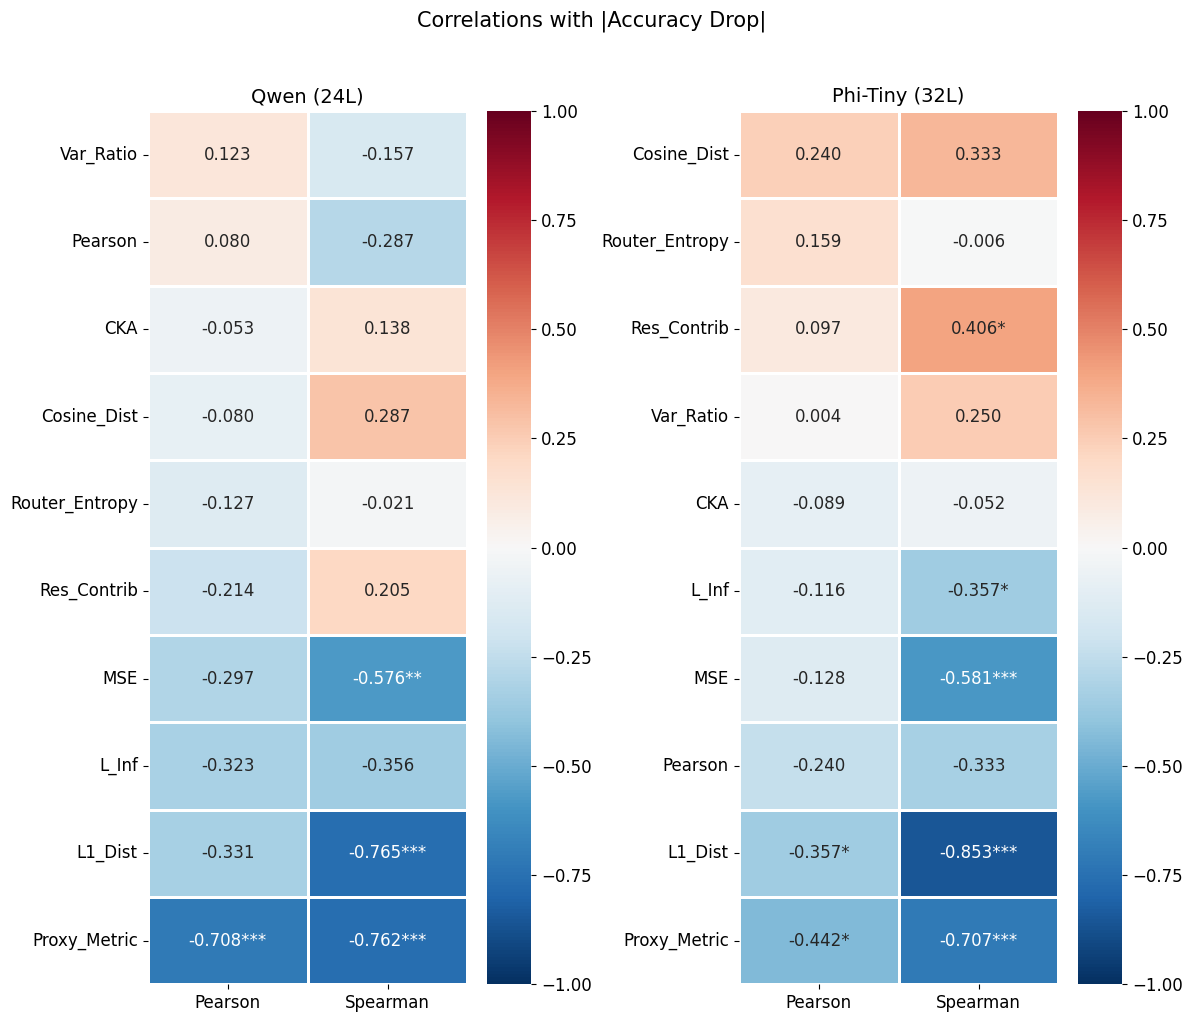

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 10))
for idx, (model, df_m, n) in enumerate([('Qwen (24L)', df_qwen, 24), ('Phi-Tiny (32L)', df_phi, 32)]):
    corrs = []
    for mn in all_metrics:
        pr, pp = stats.pearsonr(df_m['Abs_Drop'], df_m[mn])
        sr, sp = stats.spearmanr(df_m['Abs_Drop'], df_m[mn])
        corrs.append({'Metric': mn, 'Pearson': pr, 'Spearman': sr, 'P_p': pp, 'S_p': sp})
    dc = pd.DataFrame(corrs).set_index('Metric')
    dc_sorted = dc.sort_values('Pearson', ascending=False)
    data = dc_sorted[['Pearson', 'Spearman']]
    # Annotations with significance
    annot = np.empty(data.shape, dtype=object)
    for i, (_, row) in enumerate(dc_sorted.iterrows()):
        for j, (col, pcol) in enumerate([('Pearson','P_p'), ('Spearman','S_p')]):
            v, p = row[col], row[pcol]
            sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
            annot[i,j] = f'{v:.3f}{sig}'
    sns.heatmap(data, annot=annot, fmt='', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                ax=axes[idx], linewidths=1, linecolor='white')
    axes[idx].set_title(f'{model}', fontsize=14); axes[idx].set_ylabel('')
plt.suptitle('Correlations with |Accuracy Drop|', fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

## 4. Proxy Metric: scatter plots

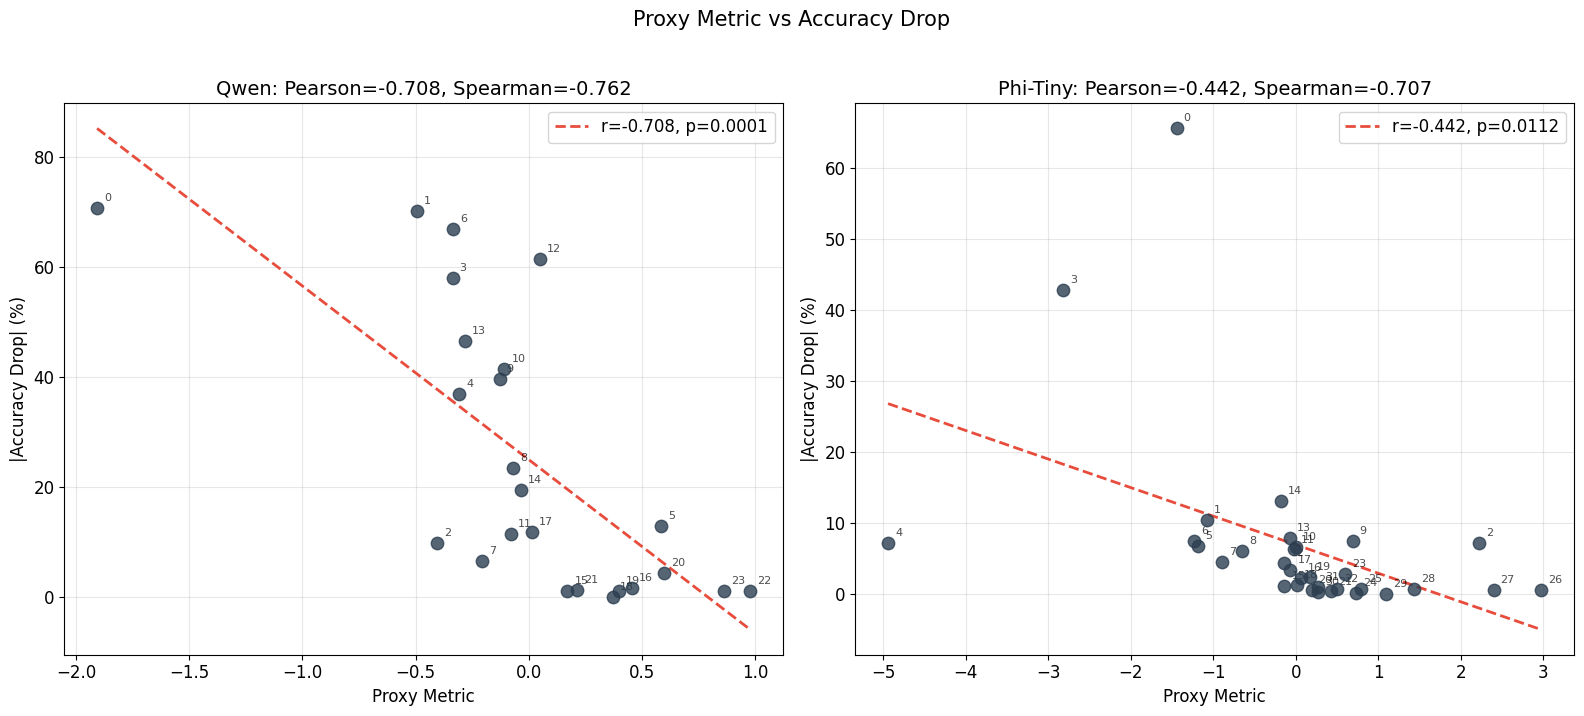

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for idx, (model, df_m) in enumerate([('Qwen', df_qwen), ('Phi-Tiny', df_phi)]):
    ax = axes[idx]
    ax.scatter(df_m['Proxy_Metric'], df_m['Abs_Drop'], s=80, c='#2c3e50', alpha=0.8, zorder=5)
    for _, row in df_m.iterrows():
        ax.annotate(str(int(row['Layer'])), (row['Proxy_Metric'], row['Abs_Drop']),
                    textcoords='offset points', xytext=(5,5), fontsize=8, alpha=0.7)
    # Regression line
    x, y = df_m['Proxy_Metric'].values, df_m['Abs_Drop'].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    xf = np.linspace(x.min(), x.max(), 100)
    ax.plot(xf, slope*xf+intercept, '--', color='#e74c3c', linewidth=2,
            label=f'r={r:.3f}, p={p:.4f}')
    pr, pp = stats.pearsonr(x, y)
    sr, sp = stats.spearmanr(x, y)
    ax.set_xlabel('Proxy Metric'); ax.set_ylabel('|Accuracy Drop| (%)')
    ax.set_title(f'{model}: Pearson={pr:.3f}, Spearman={sr:.3f}')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Proxy Metric vs Accuracy Drop', fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

## 5. Proxy Metric: line plots side-by-side

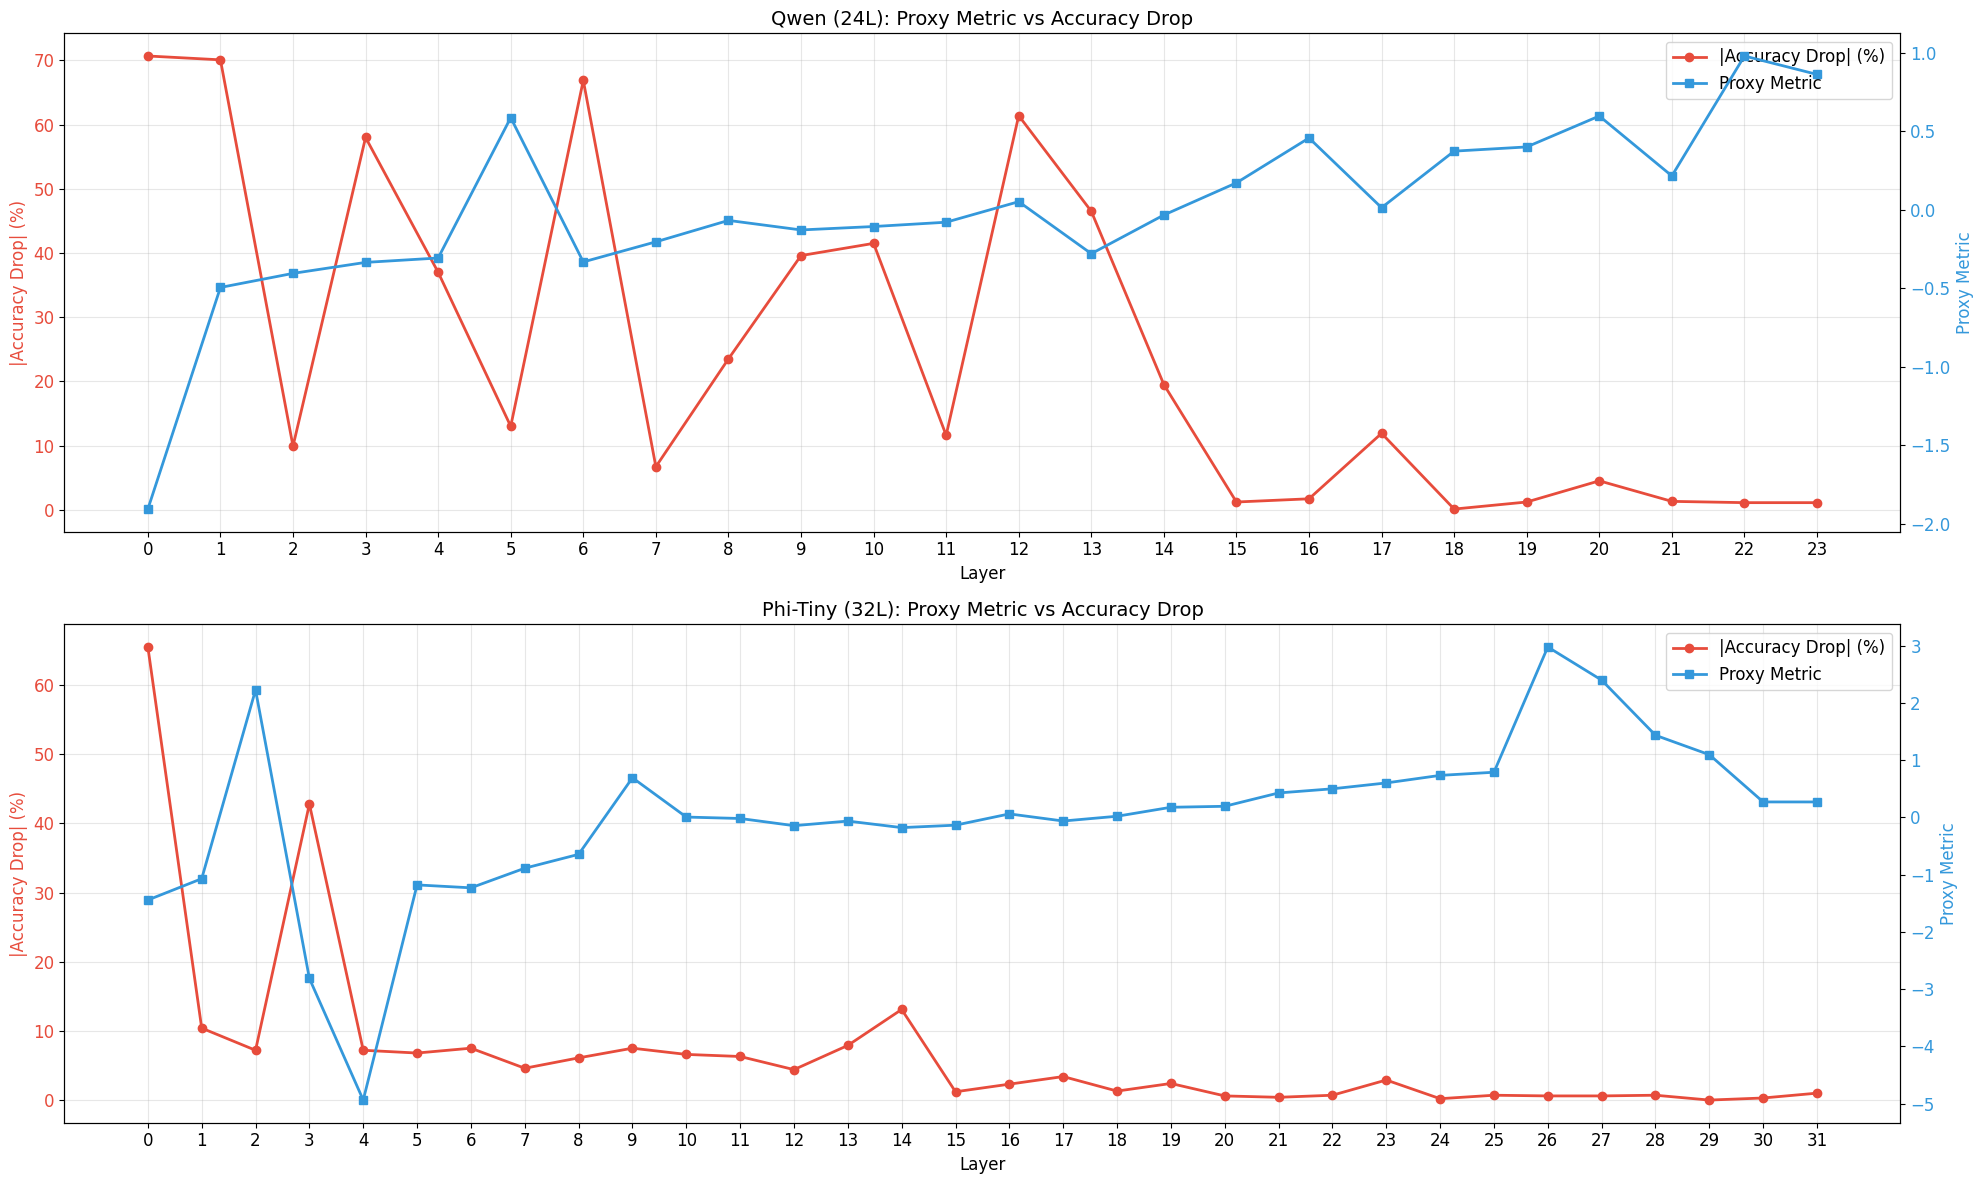

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(20, 12))
for idx, (model, df_m) in enumerate([('Qwen (24L)', df_qwen), ('Phi-Tiny (32L)', df_phi)]):
    ax1 = axes[idx]
    layers = df_m['Layer'].values
    ax1.plot(layers, df_m['Abs_Drop'], 'o-', color='#e74c3c', linewidth=2, markersize=6, label='|Accuracy Drop| (%)')
    ax1.set_xlabel('Layer'); ax1.set_ylabel('|Accuracy Drop| (%)', color='#e74c3c')
    ax1.tick_params(axis='y', labelcolor='#e74c3c'); ax1.set_xticks(layers); ax1.grid(True, alpha=0.3)
    ax2 = ax1.twinx()
    ax2.plot(layers, df_m['Proxy_Metric'], 's-', color='#3498db', linewidth=2, markersize=6, label='Proxy Metric')
    ax2.set_ylabel('Proxy Metric', color='#3498db'); ax2.tick_params(axis='y', labelcolor='#3498db')
    l1, la1 = ax1.get_legend_handles_labels(); l2, la2 = ax2.get_legend_handles_labels()
    ax1.legend(l1+l2, la1+la2, loc='upper right')
    ax1.set_title(f'{model}: Proxy Metric vs Accuracy Drop')
plt.tight_layout(); plt.show()

## 6. Rank comparison

In [7]:
def rank_comparison(df_m, model_name):
    df_r = df_m[['Layer', 'Abs_Drop', 'Proxy_Metric']].copy()
    df_r['Rank_Drop'] = df_r['Abs_Drop'].rank(ascending=False).astype(int)
    df_r['Rank_Proxy'] = df_r['Proxy_Metric'].rank(ascending=False).astype(int)
    df_r['Rank_Diff'] = (df_r['Rank_Drop'] - df_r['Rank_Proxy']).abs()
    df_r = df_r.sort_values('Rank_Drop')
    print(f'=== {model_name} ===')
    print(f'Mean rank difference: {df_r["Rank_Diff"].mean():.2f}')
    print(f'Max rank difference:  {df_r["Rank_Diff"].max()}')
    # Top-5 overlap
    top5_drop = set(df_r.nsmallest(5, 'Rank_Drop')['Layer'])
    top5_proxy = set(df_r.nsmallest(5, 'Rank_Proxy')['Layer'])
    print(f'Top-5 overlap: {len(top5_drop & top5_proxy)}/5 layers')
    print(f'Top-5 by drop:  {sorted(top5_drop)}')
    print(f'Top-5 by proxy: {sorted(top5_proxy)}')
    print()
    return df_r

df_rq = rank_comparison(df_qwen, 'Qwen')
df_rp = rank_comparison(df_phi, 'Phi-Tiny')

=== Qwen ===
Mean rank difference: 11.00
Max rank difference:  23
Top-5 overlap: 0/5 layers
Top-5 by drop:  [0, 1, 3, 6, 12]
Top-5 by proxy: [5, 16, 20, 22, 23]

=== Phi-Tiny ===
Mean rank difference: 14.69
Max rank difference:  29
Top-5 overlap: 0/5 layers
Top-5 by drop:  [0, 1, 3, 13, 14]
Top-5 by proxy: [2, 26, 27, 28, 29]



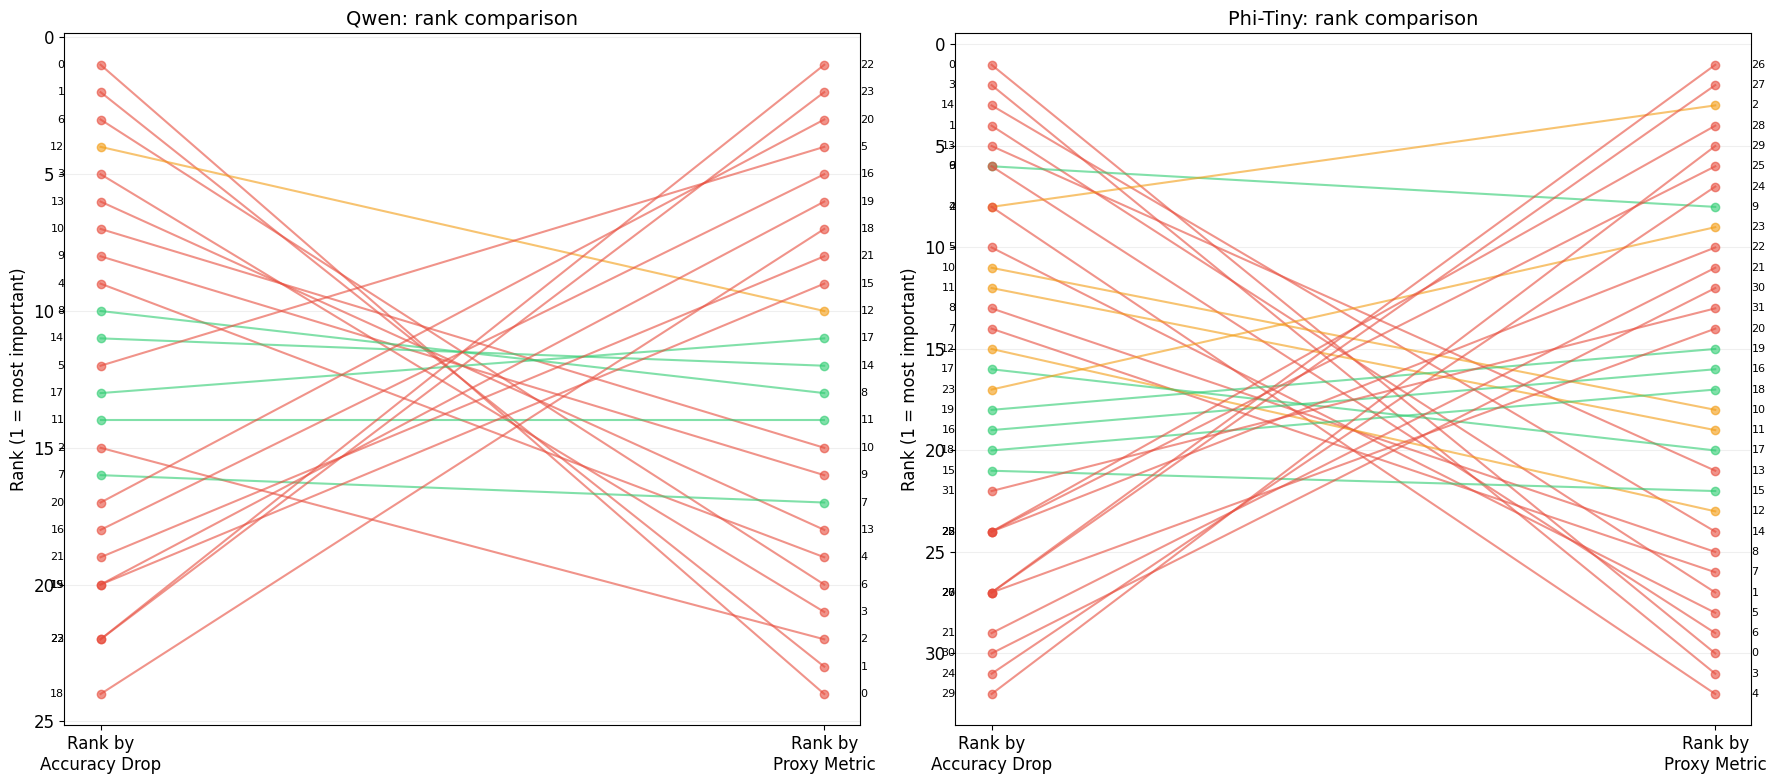

In [8]:
# Rank comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for idx, (model, df_r) in enumerate([('Qwen', df_rq), ('Phi-Tiny', df_rp)]):
    ax = axes[idx]
    n = len(df_r)
    for _, row in df_r.iterrows():
        color = '#e74c3c' if row['Rank_Diff'] > n//4 else '#f39c12' if row['Rank_Diff'] > n//8 else '#2ecc71'
        ax.plot([0, 1], [row['Rank_Drop'], row['Rank_Proxy']], '-o', color=color, alpha=0.6, markersize=6)
        ax.text(-0.05, row['Rank_Drop'], str(int(row['Layer'])), ha='right', va='center', fontsize=8)
        ax.text(1.05, row['Rank_Proxy'], str(int(row['Layer'])), ha='left', va='center', fontsize=8)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Rank by\nAccuracy Drop', 'Rank by\nProxy Metric'])
    ax.set_ylabel('Rank (1 = most important)')
    ax.set_title(f'{model}: rank comparison')
    ax.invert_yaxis(); ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout(); plt.show()

## 7. Per-metric correlation comparison

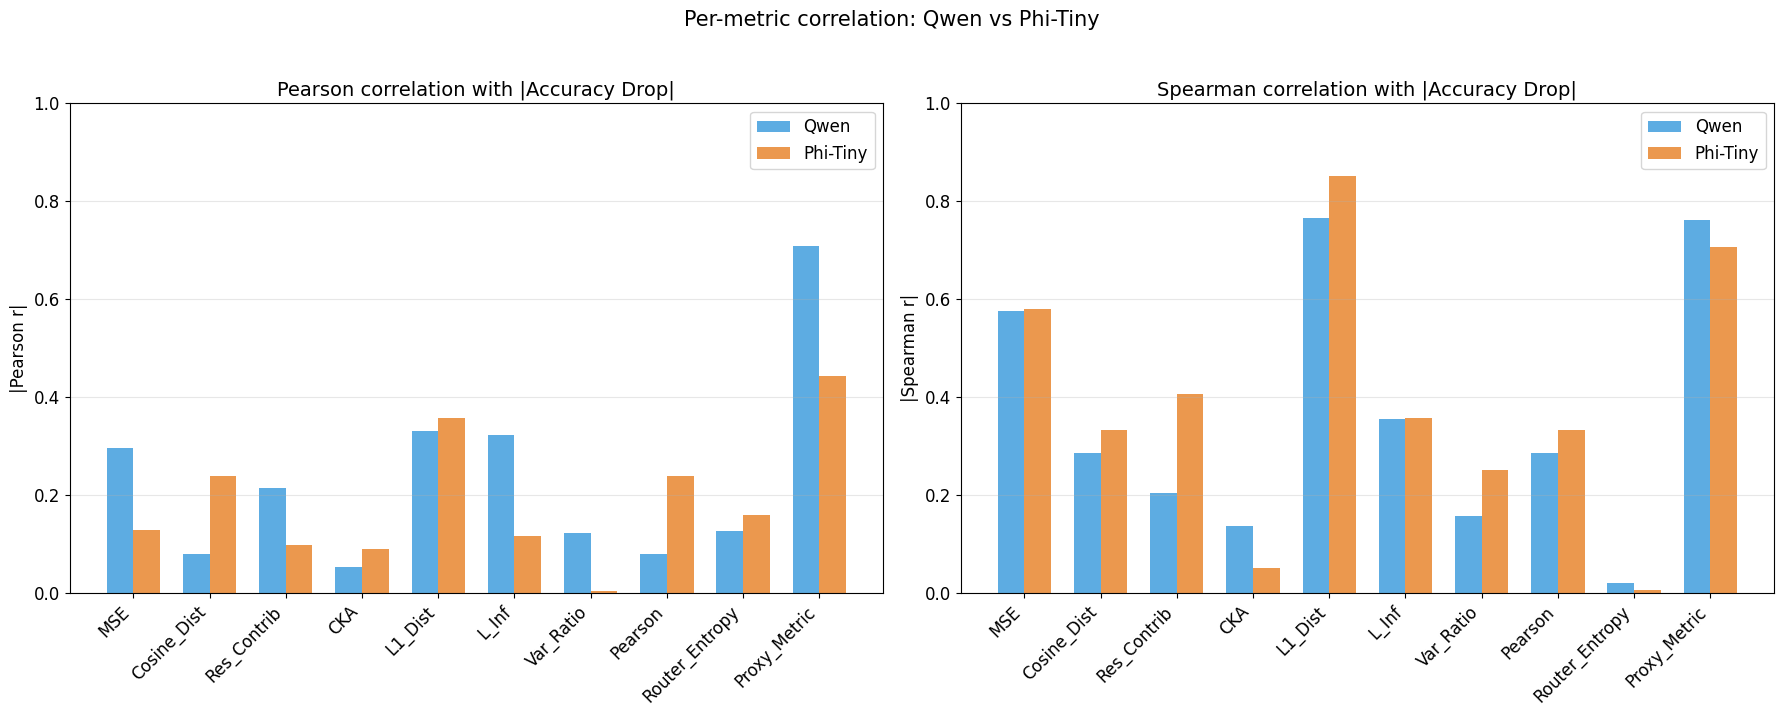

In [9]:
# Grouped bar chart: Pearson & Spearman for each metric, Qwen vs Phi
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
x = np.arange(len(all_metrics))
w = 0.35
for idx, col in enumerate(['Pearson', 'Spearman']):
    qcol = f'Qwen_{col}'; pcol = f'Phi_{col}'
    axes[idx].bar(x - w/2, df_comp[qcol].abs(), w, label='Qwen', color='#3498db', alpha=0.8)
    axes[idx].bar(x + w/2, df_comp[pcol].abs(), w, label='Phi-Tiny', color='#e67e22', alpha=0.8)
    axes[idx].set_xticks(x); axes[idx].set_xticklabels(df_comp['Metric'], rotation=45, ha='right')
    axes[idx].set_ylabel(f'|{col} r|'); axes[idx].set_title(f'{col} correlation with |Accuracy Drop|')
    axes[idx].legend(); axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].set_ylim(0, 1)
plt.suptitle('Per-metric correlation: Qwen vs Phi-Tiny', fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

## 8. Summary

In [10]:
# Summary statistics
qpr, qpp = stats.pearsonr(df_qwen['Abs_Drop'], df_qwen['Proxy_Metric'])
qsr, qsp = stats.spearmanr(df_qwen['Abs_Drop'], df_qwen['Proxy_Metric'])
ppr, ppp = stats.pearsonr(df_phi['Abs_Drop'], df_phi['Proxy_Metric'])
psr, psp = stats.spearmanr(df_phi['Abs_Drop'], df_phi['Proxy_Metric'])

summary = pd.DataFrame({
    'Model': ['Qwen 1.5 MoE (24L)', 'Phi-Tiny (32L)'],
    'Pearson_r': [round(qpr,4), round(ppr,4)],
    'Pearson_p': [round(qpp,4), round(ppp,4)],
    'Spearman_r': [round(qsr,4), round(psr,4)],
    'Spearman_p': [round(qsp,4), round(psp,4)],
    'Mean_Rank_Diff': [round(df_rq['Rank_Diff'].mean(),2), round(df_rp['Rank_Diff'].mean(),2)],
    'Top5_Overlap': [
        len(set(df_rq.nsmallest(5,'Rank_Drop')['Layer']) & set(df_rq.nsmallest(5,'Rank_Proxy')['Layer'])),
        len(set(df_rp.nsmallest(5,'Rank_Drop')['Layer']) & set(df_rp.nsmallest(5,'Rank_Proxy')['Layer']))
    ]
})
print('=== PROXY METRIC PERFORMANCE SUMMARY ===')
summary

=== PROXY METRIC PERFORMANCE SUMMARY ===


,Model,Pearson_r,Pearson_p,Spearman_r,Spearman_p,Mean_Rank_Diff,Top5_Overlap
0,Qwen 1.5 MoE (24L),-0.7080,0.0001,-0.7621,0.0,11.00,0
1,Phi-Tiny (32L),-0.4424,0.0112,-0.7070,0.0,14.69,0
